In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Preprocessing function for SAR images
def preprocess_sar_image(image_path):
    """
    Preprocess SAR image: denoise and convert to binary (pure black and white)
    Args:
        image_path: Path to the input image
    Returns:
        Preprocessed binary image as numpy array
    """
    # Read image
    img = cv2.imread(image_path)

    if img is None:
        print(f"Error reading image: {image_path}")
        return None

    # Convert to grayscale if not already
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img

    # Step 1: Apply Non-local Means Denoising (removes SAR speckle noise)
    denoised = cv2.fastNlMeansDenoising(gray, None, h=10, templateWindowSize=7, searchWindowSize=21)

    # Step 2: Apply CLAHE for strong contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    enhanced = clahe.apply(denoised)

    # Step 3: Apply histogram stretching
    enhanced = cv2.normalize(enhanced, None, 0, 255, cv2.NORM_MINMAX)

    # Step 4: Apply Otsu's Binary Thresholding for PURE BLACK AND WHITE
    # This converts the image to only 0 (black) and 255 (white) pixels
    _, binary = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    return binary

print("Preprocessing function defined!")

Preprocessing function defined!


In [ ]:
# Import required libraries
import os
import cv2
from tqdm import tqdm

# Define paths
base_path = '/content/drive/MyDrive/Sanskar_Dataset'
output_base_path = '/content/drive/MyDrive/Sanskar_dataset_preprocessed'

# Create output directories
for category in ['OilSpill', 'NoSpill']:
    for split in ['Train', 'Test']:
        output_dir = os.path.join(output_base_path, category, split)
        os.makedirs(output_dir, exist_ok=True)

# Process all images
def process_dataset():
    """
    Process all images in the dataset
    """
    total_processed = 0
    total_errors = 0

    categories = ['OilSpill', 'NoSpill']
    splits = ['Train', 'Test']

    for category in categories:
        for split in splits:
            input_dir = os.path.join(base_path, category, split)
            output_dir = os.path.join(output_base_path, category, split)

            # Check if input directory exists
            if not os.path.exists(input_dir):
                print(f"Warning: Directory does not exist: {input_dir}")
                continue

            # Get all image files
            image_files = [f for f in os.listdir(input_dir)
                          if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp'))]

            print(f"\nProcessing {category}/{split}: {len(image_files)} images")

            # Process each image with progress bar
            for img_file in tqdm(image_files, desc=f"{category}/{split}"):
                try:
                    input_path = os.path.join(input_dir, img_file)
                    output_path = os.path.join(output_dir, img_file)

                    # Preprocess image
                    preprocessed = preprocess_sar_image(input_path)

                    if preprocessed is not None:
                        # Save preprocessed image
                        cv2.imwrite(output_path, preprocessed)
                        total_processed += 1
                    else:
                        total_errors += 1

                except Exception as e:
                    print(f"Error processing {img_file}: {str(e)}")
                    total_errors += 1

    print(f"\n{'='*50}")
    print(f"Processing Complete!")
    print(f"Total images processed: {total_processed}")
    print(f"Total errors: {total_errors}")
    print(f"Output directory: {output_base_path}")
    print(f"{'='*50}")

# Run the preprocessing
process_dataset()


Processing OilSpill/Train: 914 images


OilSpill/Train: 100%|██████████| 914/914 [04:42<00:00,  3.24it/s]



Processing OilSpill/Test: 910 images


OilSpill/Test: 100%|██████████| 910/910 [04:41<00:00,  3.23it/s]



Processing NoSpill/Train: 900 images


NoSpill/Train: 100%|██████████| 900/900 [04:38<00:00,  3.24it/s]



Processing NoSpill/Test: 900 images


NoSpill/Test: 100%|██████████| 900/900 [04:37<00:00,  3.24it/s]


Processing Complete!
Total images processed: 3624
Total errors: 0
Output directory: /content/drive/MyDrive/Sanskar_dataset_preprocessed


Input dir : /content/drive/MyDrive/Sanskar_Dataset/OilSpill/Train
Output dir: /content/drive/MyDrive/Sanskar_dataset_preprocessed/OilSpill/Train
1. 1 (666).jpg -> orig: (400, 400) prep: (400, 400)
2. 1 (319).jpg -> orig: (400, 400) prep: (400, 400)
3. 1 (681).jpg -> orig: (400, 400) prep: (400, 400)
4. 1 (174).jpg -> orig: (400, 400) prep: (400, 400)


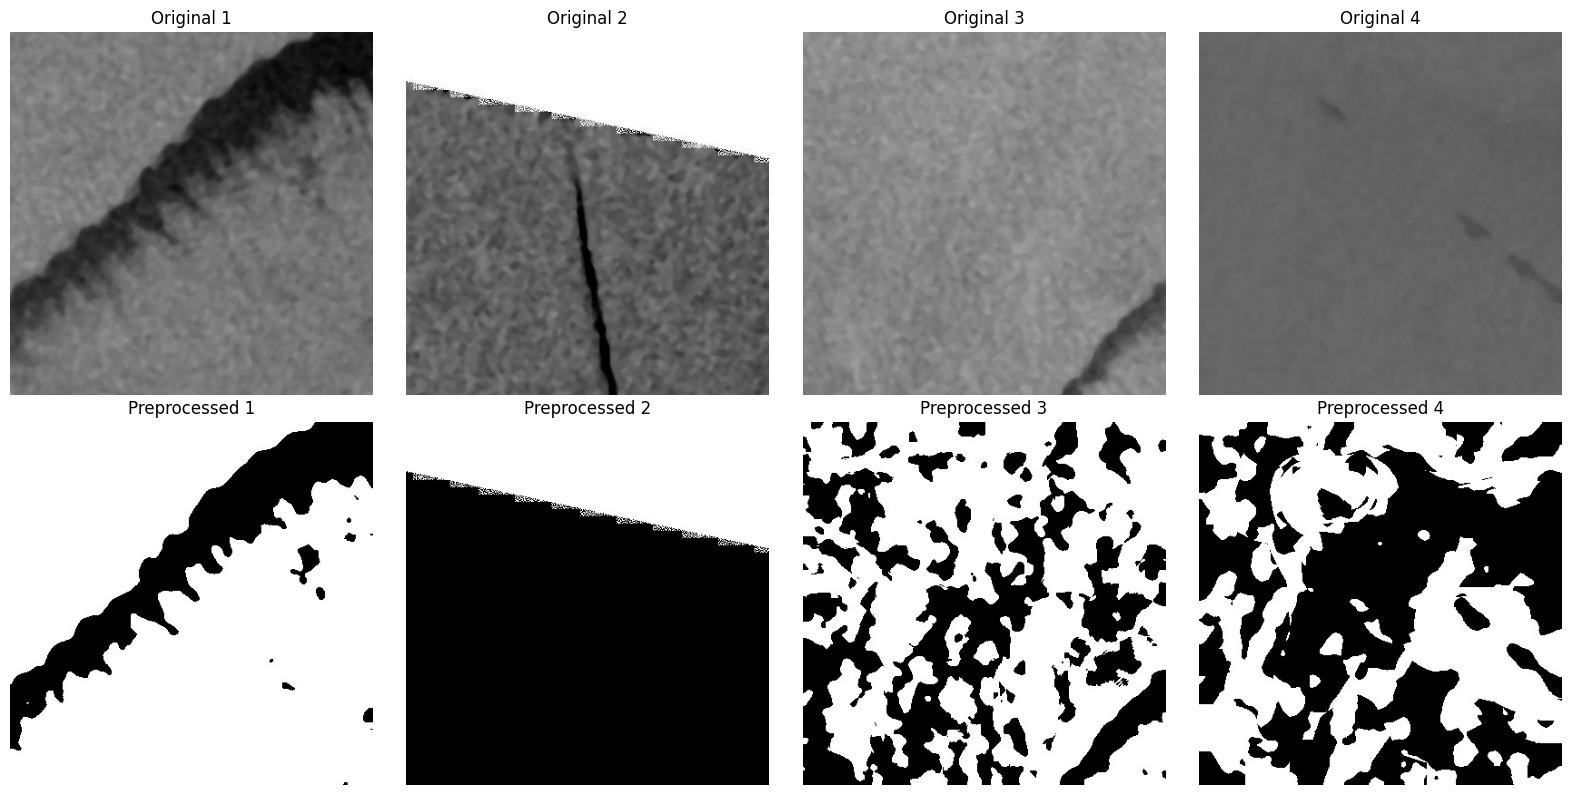

Comparison image saved to Drive!


In [ ]:
import random
import matplotlib.pyplot as plt
import cv2
import os

# Paths
input_base_path = '/content/drive/MyDrive/Sanskar_Dataset'   # note: capital D
output_base_path = '/content/drive/MyDrive/Sanskar_dataset_preprocessed'


def display_samples(num_samples=4, category='OilSpill', split='Train'):
    """
    Display sample original and preprocessed images for comparison.
    """
    # Folders (adjust names to exactly match your folder structure)
    sample_dir = os.path.join(input_base_path, category, split)
    output_sample_dir = os.path.join(output_base_path, category, split)

    print("Input dir :", sample_dir)
    print("Output dir:", output_sample_dir)

    if not os.path.exists(sample_dir):
        print("Input directory does not exist")
        return
    if not os.path.exists(output_sample_dir):
        print("Output directory does not exist")
        return

    # Collect files
    sample_files = [f for f in os.listdir(sample_dir)
                    if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))]

    if not sample_files:
        print("No images found in", sample_dir)
        return

    sample_files = sample_files[:num_samples]

    fig, axes = plt.subplots(2, len(sample_files), figsize=(4*len(sample_files), 8))

    for i, fname in enumerate(sample_files):
        orig_path = os.path.join(sample_dir, fname)
        prep_path = os.path.join(output_sample_dir, fname)

        orig_img = cv2.imread(orig_path, cv2.IMREAD_GRAYSCALE)
        prep_img = cv2.imread(prep_path, cv2.IMREAD_GRAYSCALE)

        print(f"{i+1}. {fname} -> orig:",
              None if orig_img is None else orig_img.shape,
              "prep:", None if prep_img is None else prep_img.shape)

        # Original
        if orig_img is not None:
            axes[0, i].imshow(orig_img, cmap='gray', vmin=0, vmax=255)
            axes[0, i].set_title(f'Original {i+1}')
        else:
            axes[0, i].set_title('Missing original')
        axes[0, i].axis('off')

        # Preprocessed
        if prep_img is not None:
            axes[1, i].imshow(prep_img, cmap='gray', vmin=0, vmax=255)
            axes[1, i].set_title(f'Preprocessed {i+1}')
        else:
            axes[1, i].set_title('Missing preprocessed')
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/preprocessing_comparison.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("Comparison image saved to Drive!")


display_samples()


In [ ]:
# USAGE INSTRUCTIONS:
# ===================
# 1. First, run the Drive mount cell to connect your Google Drive
# 2. Run the setup cell to import libraries and create output directories
# 3. Run the preprocessing function cell to define the image processing function
# 4. Run the process_dataset cell to process all images
# 5. Optionally, uncomment and run display_samples() to see before/after comparison
#
# PREPROCESSING TECHNIQUES USED:
# ==============================
# - Grayscale conversion: Converts color images to black and white
# - Non-local Means Denoising: Removes noise while preserving details (ideal for SAR)
# - The denoising parameters can be adjusted:
#   * h=10: Filter strength (higher = more smoothing)
#   * templateWindowSize=7: Size of patch for comparison
#   * searchWindowSize=21: Size of area to search for similar patches
#
# OUTPUT STRUCTURE:
# =================
# Sanskar_dataset_preprocessed/
#   ├── oilspill/
#   │   ├── train/
#   │   └── test/
#   └── no_spill/
#       ├── train/
#       └── test/

print("Ready to preprocess your SAR images!")

Ready to preprocess your SAR images!
